# ConvCNP Downscaling — Cross-folder analysis

Compares results across the experiment folders defined under
`projects/tessera_downscaling/scripts/experiments/`. For each folder,
runs the distribution-aware `print_summary` table per `(variable,
distribution)` family and picks the top-N variants for each family.
Then assembles cross-folder pivot tables for baselines and top variants.

**v4 update — multiple likelihood heads.** This notebook iterates
`(variable, distribution)` pairs rather than just `variable`:

  * `(t2m, gaussian)`
  * `(wind, gaussian)`           — legacy wind family
  * `(wind, weibull)`            — v4 Set A (wind-Weibull)
  * `(precip, bernoulli_gamma)`  — v4 Set B
  * `(tmax, gaussian)`           — legacy daily
  * `(wind_mean, gaussian)`      — legacy daily

Each `(variable, distribution)` pair gets its own table with a
distribution-appropriate column layout. Cross-distribution comparisons
(e.g., wind under Gaussian vs Weibull) are made via NLL and CRPS,
which are proper scoring rules and don't depend on the assumed
distribution family.

**For detailed within-folder analysis** (training curves, per-station
errors, regional breakdowns, calibration plots), use
`single_folder_analysis.ipynb` with the relevant `ACTIVE_FOLDER` set.

This notebook only depends on `_helpers.py` for loading and table
construction.


In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Local helpers — YAML-driven loader, summary tables, shortlists.
sys.path.insert(0, str(Path.cwd()))
import _helpers
import importlib
importlib.reload(_helpers)  # convenient for iterative edits to _helpers.py

warnings.filterwarnings('ignore', category=FutureWarning)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'figure.constrained_layout.use': True,
})


In [2]:
# ============================================================================
# TESSERA generation selector — pick which latents generation the paper-facing
# (+mTPI) tables and figures below use for the TESSERA arm. Baselines
# (persistence / ERA5-interp / no-TESSERA ConvCNP) are latents-independent and
# always come from the base region folders; TESSERA runs of a non-v1
# generation live in "training_runs_<region><TESS_FOLDER_SUFFIX>".
# ============================================================================

# --- current main: TESSERA v2 "1B-M", 2017 embeddings, crop64_lat16_auxon ---
TESS_GEN_LABEL     = "TESSERA 1B-M"
TESS_FOLDER_SUFFIX = "_tessera_1B-M_2017"
TESS_RUN_MTPI = {
    "t2m":  "t2m_snap_vae_crop64_lat16_auxon_concat_mtpi",
    "wind": "wind_truncnormal_snap_vae_crop64_lat16_auxon_concat_mtpi",
}
# Shuffled-latent control (paper Appendix A), EU: per var the live-vs-shuffled
# pair as (live folder suffix, live run, shuffled folder suffix, shuffled run).
TESS_SHUFFLE_SPEC = {
    "t2m":  ("_tessera_1B-M_2017", "t2m_snap_vae_crop64_lat16_auxon_concat_mtpi",
             "_tessera_1B-M_2017_shuffled",
             "t2m_snap_vae_crop64_lat16_auxon_shuffled_concat_mtpi"),
    "wind": ("_tessera_1B-M_2017", "wind_truncnormal_snap_vae_crop64_lat16_auxon_concat_mtpi",
             "_tessera_1B-M_2017_shuffled",
             "wind_truncnormal_snap_vae_crop64_lat16_auxon_shuffled_concat_mtpi"),
}

# --- previous main: TESSERA v1 16-d latents (uncomment to switch back) ------
# TESS_GEN_LABEL     = "TESSERA lat16"
# TESS_FOLDER_SUFFIX = ""
# TESS_RUN_MTPI = {
#     "t2m":  "t2m_snap_vae_lat16_concat_with_elev_mtpi_no_static_wd",
#     "wind": "wind_truncnormal_snap_vae_lat16_concat_with_elev_mtpi_no_static_wd",
# }
# # v1's shuffled control ran on the no-mTPI EU config:
# TESS_SHUFFLE_SPEC = {
#     "t2m":  ("", "t2m_snap_vae_lat16_concat_with_elev_no_static_wd",
#              "", "t2m_snap_vae_lat16_shuffled_concat_with_elev_no_static_wd"),
#     "wind": ("", "wind_truncnormal_snap_vae_lat16_concat_with_elev_no_static_wd",
#              "", "wind_truncnormal_snap_vae_lat16_shuffled_concat_with_elev_no_static_wd"),
# }

print(f"TESSERA generation: {TESS_GEN_LABEL}  (folder suffix: '{TESS_FOLDER_SUFFIX}')")

TESSERA generation: TESSERA 1B-M  (folder suffix: '_tessera_1B-M_2017')


## 1. Discover folders and load results

In [3]:
# All folders that have an experiments.yaml. Edit `FOLDERS` below to
# subset, e.g. only the 14y single-region folders.
ALL_FOLDERS = _helpers.list_folders()
print(f'Available folders ({len(ALL_FOLDERS)}):')
for f in ALL_FOLDERS:
    out_dir = _helpers.output_dir_for_folder(f)
    n_runs = len(list(out_dir.iterdir())) if out_dir.exists() else 0
    flag = '✓' if out_dir.exists() else '·'
    print(f'  {flag} {f:<32} ({n_runs} run dirs)')

# Default: load every folder that has at least one completed run.
# Override here if you want to focus on a subset (e.g. exclude 6y).
FOLDERS = ALL_FOLDERS


Available folders (30):
  ✓ snapshot_14y_aurora_zeroshot     (2 run dirs)
  ✓ snapshot_14y_australia           (676 run dirs)
  ✓ snapshot_14y_australia_tessera_1B-M_2017 (24 run dirs)
  ✓ snapshot_14y_australia_tessera_1B-M_2024 (24 run dirs)
  ✓ snapshot_14y_cross_lead          (2 run dirs)
  ✓ snapshot_14y_cross_lead_tessera_1B-M_2017 (2 run dirs)
  ✓ snapshot_14y_east_asia           (952 run dirs)
  ✓ snapshot_14y_east_asia_tessera_1B-M_2017 (48 run dirs)
  ✓ snapshot_14y_east_asia_tessera_1B-M_2024 (42 run dirs)
  ✓ snapshot_14y_eu                  (437 run dirs)
  ✓ snapshot_14y_eu_placement_norway (3 run dirs)
  ✓ snapshot_14y_eu_placement_norway_stationcount (5 run dirs)
  ✓ snapshot_14y_eu_station_count_efficiency (62 run dirs)
  ✓ snapshot_14y_eu_temporal_efficiency (74 run dirs)
  ✓ snapshot_14y_eu_temporal_efficiency_alps (74 run dirs)
  ✓ snapshot_14y_eu_temporal_efficiency_norway (74 run dirs)
  ✓ snapshot_14y_eu_temporal_rollout_alps (86 run dirs)
  ✓ snapshot_14y_eu_tem

In [4]:
SEEDS = [42, 123, 456]
df = _helpers.load_all_results(folders=FOLDERS, seeds=SEEDS)
print(f'Loaded {len(df)} run results across {df["experiment"].nunique()} '
      f'experiments and {df["source_folder"].nunique()} folders')

# (variable, distribution) pairs to iterate. Order = display order. Add
# the legacy daily-cadence variables (Gaussian only) for compat with
# any old folders still present.
TARGET_PAIRS = [
    ("t2m",       "gaussian"),
    ("wind",      "gaussian"),         # legacy wind family
    ("wind",      "weibull"),          # v4 Set A
    ("wind",      "truncated_normal"),
    ("precip",    "bernoulli_gamma"),  # v4 Set B
    ("t2m",       "generative"),       # v5 implicit CRPS-trained head
    ("wind",      "generative"),
    ("precip",    "generative"),       # only where dataset has precip
    ("tmax",      "gaussian"),         # legacy daily
    ("wind_mean", "gaussian"),         # legacy daily
]

print()
print('Counts per (folder, variable, distribution):')
for variable, distribution in TARGET_PAIRS:
    # Filter rows where THIS variable IS this distribution. The column
    # may not exist on legacy / non-v4 dataframes — fall back to gating
    # on the MAE-equivalent column existing.
    dist_col = f'{variable}_distribution'
    if dist_col in df.columns:
        sub = df[df[dist_col] == distribution]
    else:
        if distribution != 'gaussian':
            continue
        gate_col = f'{variable}_{_helpers._point_estimate_mae_column(distribution)}'
        if gate_col not in df.columns:
            continue
        sub = df[df[gate_col].notna()]
    if sub.empty:
        continue
    print(f'\n  {variable} [{distribution}]:')
    for folder, n in sub.groupby('source_folder').size().items():
        print(f'    {folder:<32} {n} runs')


Loaded 3785 run results across 399 experiments and 25 folders

Counts per (folder, variable, distribution):

  t2m [gaussian]:
    snapshot_14y_australia           204 runs
    snapshot_14y_australia_tessera_1B-M_2017 12 runs
    snapshot_14y_australia_tessera_1B-M_2024 12 runs
    snapshot_14y_east_asia           285 runs
    snapshot_14y_east_asia_tessera_1B-M_2017 24 runs
    snapshot_14y_east_asia_tessera_1B-M_2024 21 runs
    snapshot_14y_eu                  123 runs
    snapshot_14y_eu_station_count_efficiency 30 runs
    snapshot_14y_eu_temporal_efficiency 37 runs
    snapshot_14y_eu_temporal_efficiency_alps 37 runs
    snapshot_14y_eu_temporal_efficiency_norway 37 runs
    snapshot_14y_eu_temporal_rollout_alps 43 runs
    snapshot_14y_eu_temporal_rollout_norway 42 runs
    snapshot_14y_eu_temporal_rollout_norway_lat16_mtpi 61 runs
    snapshot_14y_eu_temporal_rollout_norway_tessera_1B-M_2017 30 runs
    snapshot_14y_eu_tessera_1B-M_2017 24 runs
    snapshot_14y_eu_tessera_1B-M_

## 2. Per-folder summary tables

One block per folder. Each block prints `print_summary` for every
`(variable, distribution)` family that has results in that folder, with
a distribution-appropriate column layout (Gaussian shows σ-coverage;
Weibull shows MAE@median + Bias/Corr; B-G shows PoD/FaR/Brier + wet-day
metrics). Simple baselines (era5_interp, persistence) are included
even for non-Gaussian families — they belong to those families by
experiment-name convention, even though their predictive distribution
is point-style. Their N/A entries in distribution-specific columns
are the honest signal: simple baselines don't compute probabilistic
wet-day or skew-aware metrics.


In [5]:
import pandas as pd

# One full table per (folder, variable, distribution).
for folder in FOLDERS:
    sub_folder = df[df['source_folder'] == folder]
    if sub_folder.empty:
        continue
    print(f'\n{"#" * 80}')
    print(f'#  {folder}')
    print(f'{"#" * 80}')
    for variable, distribution in TARGET_PAIRS:
        dist_col = f'{variable}_distribution'
        if dist_col in sub_folder.columns:
            sub = sub_folder[sub_folder[dist_col] == distribution]
        else:
            if distribution != 'gaussian':
                continue
            sub = sub_folder

        # Simple baselines (era5_interp, persistence) don't write head_spec
        # so the loader defaults their <var>_distribution to "gaussian" —
        # which means the filter above drops them out of non-Gaussian
        # families. Pull them back in by name from the unfiltered slice.
        baselines = _helpers.baselines_for(variable, distribution)
        baseline_rows = sub_folder[sub_folder['experiment'].isin(baselines)]
        sub_combined = pd.concat(
            [baseline_rows, sub[~sub['experiment'].isin(baselines)]],
            ignore_index=True,
        ).drop_duplicates(subset=['experiment', 'seed'])

        if sub_combined.empty:
            continue
        _helpers.print_summary(
            sub_combined, variable,
            distribution=distribution,
            title_suffix=folder,
        )



################################################################################
#  snapshot_14y_australia
################################################################################

ConvCNP RESULTS — t2m   [snapshot_14y_australia]   (australia, bbox≈15.68M km²)
Experiment                                                             MAE          RMSE     NLL(test)          CRPS    Epoch  Pred σ     1σ%     2σ%  Seeds         N Stations   st/Mkm²
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
t2m snap bilinear baseline (with elev, with static, wd=1e-4)   1.548±0.037   2.187±0.120   2.206±0.082   1.162±0.054     2±1    2.03    72.6    92.0      3      6.2K       14      0.89
t2m snap ERA5 interpolation (no model, K→°C)                   1.399±0.000   2.057±0.000   2.142±0.000           N/A     0±0    1.98    78.0    94.6      3      6.2K       1


ConvCNP RESULTS — wind [truncated_normal]   [snapshot_14y_australia]   (australia, bbox≈15.68M km²)
Experiment                                                         MAE@med     RMSE@mean     NLL(test)          CRPS    Epoch  Pred σ     1σ%     2σ%  Seeds         N Stations   st/Mkm²
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Wind (TruncNormal) snap bilinear baseline (with elev, with     1.405±0.121   1.794±0.142   1.948±0.058   1.010±0.084     2±1    1.76    68.0    94.6      3      6.2K       13      0.83
static, wd=1e-4)                                            
Wind (TruncNormal) snap bilinear baseline (with elev, with     1.329±0.037   1.710±0.044   2.089±0.100   0.971±0.025     4±1    1.25    55.7    85.1      3      6.2K       13      0.83
static, wd=1e-4, CRPS-loss)                                 
Wind (TruncNormal) snap VAE-lat16 c

## 3. Top-N shortlists per folder

For each `(folder, variable, distribution)` family, pick the top-3
TESSERA-enhanced configs by composite (MAE-equivalent, stability) rank.
Results are gathered into one dict keyed by
`(folder, variable, distribution)` for use in the cross-folder
comparison below.

Note: the same `(folder, variable)` can produce *two* shortlists if
that variable has both Gaussian and v4 runs (e.g. wind under both the
legacy Gaussian family and the v4 Weibull family). The MAE-equivalent
columns are picked per row by `shortlist_experiments` using
`<variable>_distribution`.


In [6]:
TOP_N = 3

# Key shortlists by (folder, variable, distribution).
shortlists: dict[tuple[str, str, str], list[str]] = {}

for folder in FOLDERS:
    sub_folder = df[df['source_folder'] == folder]
    if sub_folder.empty:
        continue
    for variable, distribution in TARGET_PAIRS:
        dist_col = f'{variable}_distribution'
        if dist_col in sub_folder.columns:
            sub = sub_folder[sub_folder[dist_col] == distribution]
        else:
            if distribution != 'gaussian':
                continue
            sub = sub_folder
        if sub.empty:
            continue
        names = _helpers.shortlist_experiments(
            sub, variable, top_n=TOP_N,
            tessera_only=True, print_table=False,
        )
        if names:
            shortlists[(folder, variable, distribution)] = names

print(f'Shortlists collected: {len(shortlists)} (folder, variable, distribution) cells\n')
for (folder, variable, distribution), names in shortlists.items():
    tag = f'{variable} [{distribution}]'
    print(f'  {folder} / {tag}: {names[:2]}{"..." if len(names) > 2 else ""}')


Shortlists collected: 76 (folder, variable, distribution) cells

  snapshot_14y_australia / t2m [gaussian]: ['t2m_snap_vae_lat16_proj8_concat_with_elev_no_static_wd_crps', 't2m_snap_vae_lat16_concat_with_elev_no_static_wd_crps']...
  snapshot_14y_australia / wind [gaussian]: ['wind_snap_vae_lat64_proj16_mlp_concat_with_elev_no_static_wd', 'wind_snap_vae_lat64_concat_with_elev_no_static_wd']...
  snapshot_14y_australia / wind [truncated_normal]: ['wind_truncnormal_snap_vae_lat16_concat_no_elev_no_static_wd_crps', 'wind_truncnormal_snap_vae_lat16_concat_with_elev_no_static_wd_crps']...
  snapshot_14y_australia / t2m [generative]: ['t2m_generative_snap_vae_lat16_concat_with_elev_no_static_wd', 't2m_generative_snap_vae_lat16_film_with_elev_no_static_wd']
  snapshot_14y_australia / wind [generative]: ['wind_generative_snap_vae_lat16_concat_with_elev_no_static_wd']
  snapshot_14y_australia_tessera_1B-M_2017 / t2m [gaussian]: ['t2m_snap_vae_crop64_lat16_auxon_concat_mtpi', 't2m_snap_vae_crop6

## 4. Compact per-folder summaries (baseline + top 3)

Same layout as section 2's `print_summary` tables, but filtered to just
the baselines + top-3 TESSERA variants per `(folder, variable,
distribution)`. Useful for a quick read on where each folder landed
without scrolling through all configs.

For non-Gaussian families (Weibull wind, B-G precip), simple baselines
show N/A in distribution-specific columns (PoD/FaR/Brier, wet-day
metrics, etc.) because they're point-prediction methods that don't
compute those quantities. NLL is the column to read across families
for cross-distribution comparison — it's a proper scoring rule with
the same direction (lower is better) regardless of distribution.


In [7]:
# =============================================================================
# Centralised slice analysis — config-driven classification + pairing tables.
#
# For each (folder, variable, distribution) cell, prints:
#   1. Simple baselines (uncapped)
#   2. Trained baselines, no TESSERA (uncapped)
#   3. Top-5 vanilla TESSERA (kernels mixed)
#   4. Top-5 TESSERA + new mechanism
#   5. Shuffled-control pairing for top rows in 3 + 4
#   6. Detached-control pairing for top rows in 4 (the new attention ablation)
#   7. Kernel-swap pairing for top rows in 3 (bilinear ↔ setconv siblings)
#
# Multi-task results print only tables 1-3 in a separate section per folder.
# UNKNOWN-classification runs surface in a warnings block at the end of each
# slice so legacy / corrupt configs are visible rather than silently dropped.
# =============================================================================

TOP_N_NEW = 5

_helpers.print_centralised_analysis(
    df,
    folders=FOLDERS,
    target_pairs=TARGET_PAIRS,
    top_n=TOP_N_NEW,
)


################################################################################
#  snapshot_14y_australia
################################################################################

ConvCNP RESULTS — t2m   [snapshot_14y_australia — single-task — simple baselines]   (australia, bbox≈15.68M km²)
Experiment                                                             MAE          RMSE     NLL(test)          CRPS    Epoch  Pred σ     1σ%     2σ%  Seeds         N Stations   st/Mkm²
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
t2m snap ERA5 interpolation (no model, K→°C)                   1.399±0.000   2.057±0.000   2.142±0.000           N/A     0±0    1.98    78.0    94.6      3      6.2K       14      0.89
t2m snap persistence (most recent valid obs ≤24h)              5.595±0.000   6.619±0.000   3.309±0.000           N/A     0±0    6.62    64.9


ConvCNP RESULTS — t2m   [snapshot_14y_australia_tessera_1B-M_2017 — single-task — top 5 vanilla TESSERA (VAE)]   (australia, bbox≈15.68M km²)
Experiment                                                             MAE          RMSE     NLL(test)          CRPS    Epoch  Pred σ     1σ%     2σ%  Seeds         N Stations   st/Mkm²
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
t2m VAE crop64-lat16 auxon concat (elev + mTPI, no static,     1.323±0.031   1.922±0.053   2.019±0.013   0.977±0.028    21±5    1.59    69.6    91.8      3      6.2K       14      0.89
wd=1e-4)                                                    
t2m VAE crop64-lat16 auxoff concat (elev + mTPI, no static,    1.335±0.029   1.946±0.057   2.047±0.012   0.984±0.023    20±5    1.53    68.2    90.7      3      6.2K       14      0.89
wd=1e-4)                                              

In [8]:
# =============================================================================
# mTPI ablation — with vs without mTPI (isolated view).
#
# Restricted to the two paper baselines, each trained with vs without the mTPI
# per-station feature (--use-mtpi):
#   * ConvCNP no-TESSERA baseline (bilinear)
#   * TESSERA VAE-lat16 direct-concat
# Heads match the main runs: Gaussian for t2m, truncated-normal for wind.
# Metrics use the head-resolved <var>_point_mae / _point_rmse columns + crps,
# so t2m and wind read consistently. Seed-mean over SEEDS; NaN / 0 seeds where
# a variant has not finished training.
# =============================================================================

# (model label, variable, head, base experiment [no mTPI], +mTPI experiment)
MTPI_PAIRS = [
    ("ConvCNP baseline",     "t2m",  "gaussian",
     "t2m_snap_bilinear_baseline_wd",
     "t2m_snap_bilinear_baseline_mtpi_wd"),
    ("TESSERA lat16 concat", "t2m",  "gaussian",
     "t2m_snap_vae_lat16_concat_with_elev_no_static_wd",
     "t2m_snap_vae_lat16_concat_with_elev_mtpi_no_static_wd"),
    ("ConvCNP baseline",     "wind", "truncated_normal",
     "wind_truncnormal_snap_bilinear_baseline_wd",
     "wind_truncnormal_snap_bilinear_baseline_mtpi_wd"),
    ("TESSERA lat16 concat", "wind", "truncated_normal",
     "wind_truncnormal_snap_vae_lat16_concat_with_elev_no_static_wd",
     "wind_truncnormal_snap_vae_lat16_concat_with_elev_mtpi_no_static_wd"),
]
MTPI_METRICS = ["point_mae", "point_rmse", "crps"]   # head-resolved; NaN-safe


def _mtpi_seed_mean(rows, col):
    """Seed-mean of a metric column (NaN-safe); returns (mean, n_seeds)."""
    if col not in rows.columns or rows.empty:
        return float("nan"), 0
    vals = pd.to_numeric(rows[col], errors="coerce").dropna()
    return (float(vals.mean()) if len(vals) else float("nan"), int(len(vals)))


_pair_names = {b for *_, b, _ in MTPI_PAIRS} | {m for *_, m in MTPI_PAIRS}
_mtpi_recs = []
for folder in FOLDERS:
    fdf = df[df["source_folder"] == folder]
    if fdf.empty or not (set(fdf["experiment"]) & _pair_names):
        continue  # skip folders that don't contain these experiments
    region = folder.replace("snapshot_14y_", "").replace("snapshot_6y_", "6y_")
    for label, var, head, base_name, mtpi_name in MTPI_PAIRS:
        base = fdf[fdf["experiment"] == base_name]
        mtpi = fdf[fdf["experiment"] == mtpi_name]
        rec = {"region": region, "model": label, "var": var, "head": head}
        for m in MTPI_METRICS:
            short = m.replace("point_", "")
            b, _ = _mtpi_seed_mean(base, f"{var}_{m}")
            t, _ = _mtpi_seed_mean(mtpi, f"{var}_{m}")
            rec[short] = b
            rec[short + "+mtpi"] = t
            rec["d_" + short] = t - b
            if short == "mae":
                rec["d_mae%"] = (t - b) / b * 100 if (b == b and b != 0) else float("nan")
        rec["seeds"] = f"{len(base)}/{len(mtpi)}"
        _mtpi_recs.append(rec)

mtpi_table = pd.DataFrame(_mtpi_recs)

if mtpi_table.empty:
    print("No matching runs found for the mTPI ablation experiments yet.")
else:
    mtpi_table = mtpi_table.sort_values(["var", "model", "region"]).reset_index(drop=True)

    print("mTPI ablation -- point MAE, without vs with mTPI "
          "(seed-mean; d_mae<0 => mTPI helps):\n")
    with pd.option_context("display.float_format", lambda v: f"{v:0.4f}",
                           "display.max_rows", None, "display.width", 220):
        display(mtpi_table[["region", "model", "var", "head",
                            "mae", "mae+mtpi", "d_mae", "d_mae%", "seeds"]])

    print("\nAll metrics (mae / rmse / crps), without vs with mTPI:\n")
    with pd.option_context("display.float_format", lambda v: f"{v:0.4f}",
                           "display.max_rows", None, "display.width", 240):
        display(mtpi_table)

    # Does mTPI shift the TESSERA-over-baseline gap? (the key ablation question)
    # gap = baseline_MAE - tessera_MAE (positive => TESSERA better). d_gap ~ 0
    # means mTPI lifts both arms about equally, so TESSERA's edge is preserved.
    _gap = []
    for (region, var), g in mtpi_table.groupby(["region", "var"]):
        base = g[g["model"] == "ConvCNP baseline"]
        tess = g[g["model"] == "TESSERA lat16 concat"]
        if base.empty or tess.empty:
            continue
        b_no, b_mt = base["mae"].iloc[0], base["mae+mtpi"].iloc[0]
        t_no, t_mt = tess["mae"].iloc[0], tess["mae+mtpi"].iloc[0]
        _gap.append({"region": region, "var": var,
                     "gap_noMTPI": b_no - t_no, "gap_MTPI": b_mt - t_mt,
                     "d_gap": (b_mt - t_mt) - (b_no - t_no)})
    gap_table = pd.DataFrame(_gap)
    if not gap_table.empty:
        print("\nTESSERA-over-baseline MAE gap -- preserved under mTPI? "
              "(d_gap~0 => both arms lift equally):\n")
        with pd.option_context("display.float_format", lambda v: f"{v:0.4f}"):
            display(gap_table.sort_values(["var", "region"]).reset_index(drop=True))


mTPI ablation -- point MAE, without vs with mTPI (seed-mean; d_mae<0 => mTPI helps):



,region,model,var,head,mae,mae+mtpi,d_mae,d_mae%,seeds
0,6y_eu,ConvCNP baseline,t2m,gaussian,1.2333,NaN,NaN,NaN,3/0
1,australia,ConvCNP baseline,t2m,gaussian,1.5484,1.5734,0.0250,1.6150,3/3
2,east_asia,ConvCNP baseline,t2m,gaussian,1.2910,1.3472,0.0562,4.3534,3/3
3,eu,ConvCNP baseline,t2m,gaussian,1.1724,1.1689,-0.0034,-0.2932,3/3
4,southern_africa,ConvCNP baseline,t2m,gaussian,1.9871,1.9983,0.0112,0.5630,3/3
5,us,ConvCNP baseline,t2m,gaussian,1.4148,1.4132,-0.0016,-0.1101,3/3
6,6y_eu,TESSERA lat16 concat,t2m,gaussian,1.2132,NaN,NaN,NaN,3/0
7,australia,TESSERA lat16 concat,t2m,gaussian,1.3786,1.3620,-0.0167,-1.2079,3/3
8,east_asia,TESSERA lat16 concat,t2m,gaussian,1.0921,1.1060,0.0138,1.2674,3/3
9,eu,TESSERA lat16 concat,t2m,gaussian,1.1039,1.1095,0.0056,0.5033,3/3



All metrics (mae / rmse / crps), without vs with mTPI:



,region,model,var,head,mae,mae+mtpi,d_mae,d_mae%,rmse,rmse+mtpi,d_rmse,crps,crps+mtpi,d_crps,seeds
0,6y_eu,ConvCNP baseline,t2m,gaussian,1.2333,NaN,NaN,NaN,1.8380,NaN,NaN,0.8909,NaN,NaN,3/0
1,australia,ConvCNP baseline,t2m,gaussian,1.5484,1.5734,0.0250,1.6150,2.1872,2.1635,-0.0236,1.1616,1.1489,-0.0127,3/3
2,east_asia,ConvCNP baseline,t2m,gaussian,1.2910,1.3472,0.0562,4.3534,1.7979,1.8666,0.0687,0.9338,0.9737,0.0398,3/3
3,eu,ConvCNP baseline,t2m,gaussian,1.1724,1.1689,-0.0034,-0.2932,1.6723,1.6727,0.0003,0.8421,0.8426,0.0005,3/3
4,southern_africa,ConvCNP baseline,t2m,gaussian,1.9871,1.9983,0.0112,0.5630,2.7258,2.7493,0.0234,1.4562,1.4467,-0.0095,3/3
5,us,ConvCNP baseline,t2m,gaussian,1.4148,1.4132,-0.0016,-0.1101,2.0716,2.0705,-0.0012,1.0314,1.0286,-0.0027,3/3
6,6y_eu,TESSERA lat16 concat,t2m,gaussian,1.2132,NaN,NaN,NaN,1.8110,NaN,NaN,0.8764,NaN,NaN,3/0
7,australia,TESSERA lat16 concat,t2m,gaussian,1.3786,1.3620,-0.0167,-1.2079,1.9756,1.9653,-0.0103,1.0166,1.0083,-0.0083,3/3
8,east_asia,TESSERA lat16 concat,t2m,gaussian,1.0921,1.1060,0.0138,1.2674,1.5213,1.5405,0.0191,0.7851,0.7943,0.0092,3/3
9,eu,TESSERA lat16 concat,t2m,gaussian,1.1039,1.1095,0.0056,0.5033,1.5853,1.5903,0.0050,0.7930,0.7970,0.0039,3/3



TESSERA-over-baseline MAE gap -- preserved under mTPI? (d_gap~0 => both arms lift equally):



,region,var,gap_noMTPI,gap_MTPI,d_gap
0,6y_eu,t2m,0.0201,NaN,NaN
1,australia,t2m,0.1697,0.2114,0.0417
2,east_asia,t2m,0.1989,0.2412,0.0424
3,eu,t2m,0.0684,0.0594,-0.0090
4,southern_africa,t2m,0.1631,0.1519,-0.0112
5,us,t2m,0.1292,0.1325,0.0033
6,6y_eu,wind,0.1296,NaN,NaN
7,australia,wind,0.1911,0.2094,0.0183
8,east_asia,wind,0.1036,0.0818,-0.0218
9,eu,wind,0.0970,0.0828,-0.0142


### Extra analysis

In [9]:
# ============================================================================
# lat16-direct concat summary table, across regions, for:
#     t2m  [gaussian]   and   wind [truncated_normal]
# Rows per (region, variable): persistence, ERA5-interp, no-TESSERA ConvCNP
# (bilinear), and TESSERA lat16-direct concat. Columns mirror
# print_centralised_analysis / _print_*_table in _helpers.py:
#   MAE, RMSE, NLL(test), CRPS, Epoch, Seeds, N, Stations, st/Mkm^2
# plus the region bbox area. MAE/RMSE are the head-aware point estimates
# (Gaussian -> mae/rmse; truncated_normal -> mae_at_median/rmse_at_mean),
# exactly as _load_run_record resolves them. MAE/RMSE/NLL/CRPS are shown as
# mean ±sample-std across the seeds.
# ============================================================================
import json
from pathlib import Path
import numpy as np
import pandas as pd

# ---- EDIT ME ---------------------------------------------------------------
BASE_DIR = Path("/projects/u6do/pmms2/end-to-end-forecasting"
                "/projects/tessera_downscaling/.tmp_output")
SEEDS = [42, 123, 456]
REGIONS = ["snapshot_14y_east_asia", "snapshot_14y_us",
           "snapshot_14y_southern_africa", "snapshot_14y_australia",
           "snapshot_6y_eu", "snapshot_14y_eu"]

# bbox (deg) -> area km^2, lat-cosine corrected  (from _helpers._REGION_BBOXES_DEG)
_BBOX_DEG = {
    "europe": (35.0, 75.0, -24.0, 40.0), "us": (24.0, 50.0, -125.0, -66.0),
    "east_asia": (20.0, 46.0, 100.0, 146.0), "australia": (-44.0, -10.0, 112.0, 154.0),
    "southern_africa": (-35.0, -15.0, 15.0, 35.0),
}
def _bbox_area_km2(a, b, c, d):
    import math
    cos_lat = math.cos(math.radians(0.5 * (a + b)))
    return abs((b - a) * 111.0 * (d - c) * 111.0 * cos_lat)
BBOX_AREA = {k: _bbox_area_km2(*v) for k, v in _BBOX_DEG.items()}
def _region_key(folder):
    fn = folder.lower()
    # longest key first: 'us' is a substring of 'australia' -> must not win.
    for r in sorted(BBOX_AREA, key=len, reverse=True):
        if r in fn:
            return r
    return "europe" if ("eu" in fn and "europe" not in fn) else None

# Head-aware point-estimate column (from _helpers._point_estimate_*_column).
_MAE_COL = {"gaussian": "mae", "truncated_normal": "mae_at_median"}
_RMSE_COL = {"gaussian": "rmse", "truncated_normal": "rmse_at_mean"}

# Per (variable, dist): ordered rows -> (display label, run-name).
# persistence/interp are head-agnostic data lookups -> live under the
# gaussian-family names even for the truncated_normal wind table.
CELLS = {
    ("t2m", "gaussian"): [
        ("persistence",        "t2m_snap_persistence_baseline"),
        ("ERA5-interp",        "t2m_snap_era5_interp_baseline"),
        ("no-TESSERA ConvCNP", "t2m_snap_bilinear_baseline_wd"),
        ("TESSERA lat16",      "t2m_snap_vae_lat16_concat_with_elev_no_static_wd"),
    ],
    ("wind", "truncated_normal"): [
        ("persistence",        "wind_snap_persistence_baseline"),
        ("ERA5-interp",        "wind_snap_era5_interp_baseline"),
        ("no-TESSERA ConvCNP", "wind_truncnormal_snap_bilinear_baseline_wd"),
        ("TESSERA lat16",      "wind_truncnormal_snap_vae_lat16_concat_with_elev_no_static_wd"),
    ],
}

def _read(run_dir, var):
    """Return per-seed dict of metrics from one run dir, or None."""
    res = None
    for fn in ("test_summary.json", "test_results.json"):
        p = run_dir / fn
        if p.exists():
            try:
                res = json.loads(p.read_text()); break
            except (json.JSONDecodeError, ValueError):
                continue
    if res is None:
        return None
    hs = res.get("head_spec") or {}
    dist = hs.get(var, {}).get("distribution", "gaussian")
    # trunc-normal stale-file alias (mirrors _load_run_record).
    if dist == "truncated_normal":
        for old, new in (("mae", "mae_at_median"), ("rmse", "rmse_at_mean")):
            ok, nk = f"{var}_{old}", f"{var}_{new}"
            if nk not in res and ok in res:
                res[nk] = res[ok]
    g = lambda k: res.get(f"{var}_{k}")
    return dict(
        mae=g(_MAE_COL.get(dist, "mae")), rmse=g(_RMSE_COL.get(dist, "rmse")),
        nll=g("nll"), crps=g("crps"),
        n=g("n_predictions"), stations=g("n_test_stations"),
        epoch=res.get("checkpoint_epoch", res.get("best_epoch")),
    )

def _agg(region, run_name, var):
    """Per-metric (mean, sample-std) over seeds. Keeps a[k] as the seed-mean
    (back-compatible) and adds a[k+'_std'] = cross-seed sample std (ddof=1;
    0.0 for deterministic refs / single seed)."""
    recs = []
    for s in SEEDS:
        r = _read(BASE_DIR / f"training_runs_{region}" / f"{run_name}_seed{s}", var)
        if r is not None:
            recs.append(r)
    if not recs:
        return None
    def ms(k):
        vals = [r[k] for r in recs if r[k] is not None and r[k] == r[k]]
        if not vals:
            return float("nan"), float("nan")
        mean = float(np.mean(vals))
        std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
        return mean, std
    out = {"n_seeds": len(recs)}
    for k in ("mae", "rmse", "nll", "crps", "epoch", "n", "stations"):
        out[k], out[k + "_std"] = ms(k)
    return out

def _fmt(x, p=4):
    return "—" if (x is None or x != x) else f"{x:.{p}f}"

def _pm(mean, std, p=3):
    """'mean ±std' across seeds; '—' if mean missing; no ± when std == 0
    (deterministic references such as persistence / ERA5-interp)."""
    if mean is None or mean != mean:
        return "—"
    if std is None or std != std or std == 0.0:
        return f"{mean:.{p}f}"
    return f"{mean:.{p}f} ±{std:.{p}f}"

def _build_summary(cells):
    rows = []
    for region in REGIONS:
        rkey = _region_key(region)
        bbox = BBOX_AREA.get(rkey)
        for (var, dist), runs in cells.items():
            for label, run_name in runs:
                a = _agg(region, run_name, var)
                if a is None:
                    continue
                ns = a["stations"]
                dens = (ns / (bbox / 1e6)) if (bbox and ns == ns) else float("nan")
                rows.append({
                    "region": region.replace("snapshot_", ""),
                    "var": var, "dist": dist, "model": label,
                    "MAE": _pm(a["mae"], a["mae_std"]),
                    "RMSE": _pm(a["rmse"], a["rmse_std"]),
                    "NLL(test)": _pm(a["nll"], a["nll_std"]),
                    "CRPS": _pm(a["crps"], a["crps_std"]),
                    "Epoch": ("—" if a["epoch"] != a["epoch"] else f"{a['epoch']:.0f}"),
                    "Seeds": a["n_seeds"],
                    "N": ("—" if a["n"] != a["n"] else f"{int(a['n']):,}"),
                    "Stations": ("—" if ns != ns else f"{int(ns)}"),
                    "st/Mkm2": _fmt(dens, 2),
                    "bbox_Mkm2": ("—" if not bbox else f"{bbox/1e6:.2f}"),
                })
    return pd.DataFrame(rows)

def _show_summary(summary, title):
    print(title)
    print("MAE/RMSE/NLL/CRPS = mean ±sample-std over seeds (head-aware point "
          "estimates; gaussian: mean, trunc-normal: median/mean).")
    print("Epoch/N/Stations are seed-averaged; '—' = run not present.\n")
    sty = (summary.style.hide(axis="index")
           .set_properties(subset=["MAE", "RMSE", "NLL(test)", "CRPS"],
                           **{"text-align": "right"}))
    display(sty)

summary = _build_summary(CELLS)
_show_summary(summary,
              "lat16-direct concat — t2m [gaussian] & wind [truncated_normal], across regions.")


lat16-direct concat — t2m [gaussian] & wind [truncated_normal], across regions.
MAE/RMSE/NLL/CRPS = mean ±sample-std over seeds (head-aware point estimates; gaussian: mean, trunc-normal: median/mean).
Epoch/N/Stations are seed-averaged; '—' = run not present.



region,var,dist,model,MAE,RMSE,NLL(test),CRPS,Epoch,Seeds,N,Stations,st/Mkm2,bbox_Mkm2
14y_east_asia,t2m,gaussian,persistence,3.069,4.045,2.816 ±0.000,—,0,3,"124,350",88,7.12,12.36
14y_east_asia,t2m,gaussian,ERA5-interp,1.358,1.925,2.074,—,0,3,"124,567",88,7.12,12.36
14y_east_asia,t2m,gaussian,no-TESSERA ConvCNP,1.291 ±0.010,1.798 ±0.021,2.009 ±0.025,0.934 ±0.002,3,3,"124,567",88,7.12,12.36
14y_east_asia,t2m,gaussian,TESSERA lat16,1.092 ±0.006,1.521 ±0.006,1.810 ±0.019,0.785 ±0.003,9,3,"124,567",88,7.12,12.36
14y_east_asia,wind,truncated_normal,persistence,1.456,2.044,2.134,—,0,3,"124,204",88,7.12,12.36
14y_east_asia,wind,truncated_normal,ERA5-interp,1.443,1.986,2.105,—,0,3,"124,426",88,7.12,12.36
14y_east_asia,wind,truncated_normal,no-TESSERA ConvCNP,1.247 ±0.017,1.723 ±0.033,1.803 ±0.017,0.898 ±0.013,1,3,"124,426",88,7.12,12.36
14y_east_asia,wind,truncated_normal,TESSERA lat16,1.143 ±0.002,1.600 ±0.011,1.690 ±0.008,0.819 ±0.006,3,3,"124,426",88,7.12,12.36
14y_us,t2m,gaussian,persistence,3.798 ±0.000,5.290,3.085 ±0.000,—,0,3,"190,881",355,23.52,15.09
14y_us,t2m,gaussian,ERA5-interp,1.536,2.234,2.223,—,0,3,"195,030",357,23.65,15.09


In [10]:
# ============================================================================
# Same summary table as above, but for the +mTPI variants of the two TRAINED
# models (no-TESSERA ConvCNP + TESSERA concat; the TESSERA generation is
# picked by the selector cell at the top). persistence / ERA5-interp are
# head-agnostic references with no mTPI variant, kept identical for context.
# The TESSERA row resolves from <region><TESS_FOLDER_SUFFIX>; regions without
# that folder (e.g. snapshot_6y_eu for 1B-M) simply omit the row. Reuses
# _agg / _region_key / BBOX_AREA / _pm / _fmt / _show_summary / REGIONS /
# SEEDS / BASE_DIR from the cell above — run that cell first.
# ============================================================================
CELLS_MTPI = {  # (display label, folder suffix, run name)
    ("t2m", "gaussian"): [
        ("persistence",              "", "t2m_snap_persistence_baseline"),
        ("ERA5-interp",              "", "t2m_snap_era5_interp_baseline"),
        ("no-TESSERA ConvCNP +mTPI", "", "t2m_snap_bilinear_baseline_mtpi_wd"),
        (TESS_GEN_LABEL + " +mTPI",  TESS_FOLDER_SUFFIX, TESS_RUN_MTPI["t2m"]),
    ],
    ("wind", "truncated_normal"): [
        ("persistence",              "", "wind_snap_persistence_baseline"),
        ("ERA5-interp",              "", "wind_snap_era5_interp_baseline"),
        ("no-TESSERA ConvCNP +mTPI", "", "wind_truncnormal_snap_bilinear_baseline_mtpi_wd"),
        (TESS_GEN_LABEL + " +mTPI",  TESS_FOLDER_SUFFIX, TESS_RUN_MTPI["wind"]),
    ],
}

def _build_summary_mtpi(cells):
    """_build_summary with a per-row folder suffix (generation-aware rows)."""
    rows = []
    for region in REGIONS:
        rkey = _region_key(region)
        bbox = BBOX_AREA.get(rkey)
        for (var, dist), runs in cells.items():
            for label, suffix, run_name in runs:
                a = _agg(region + suffix, run_name, var)
                if a is None:
                    continue
                ns = a["stations"]
                dens = (ns / (bbox / 1e6)) if (bbox and ns == ns) else float("nan")
                rows.append({
                    "region": region.replace("snapshot_", ""),
                    "var": var, "dist": dist, "model": label,
                    "MAE": _pm(a["mae"], a["mae_std"]),
                    "RMSE": _pm(a["rmse"], a["rmse_std"]),
                    "NLL(test)": _pm(a["nll"], a["nll_std"]),
                    "CRPS": _pm(a["crps"], a["crps_std"]),
                    "Epoch": ("—" if a["epoch"] != a["epoch"] else f"{a['epoch']:.0f}"),
                    "Seeds": a["n_seeds"],
                    "N": ("—" if a["n"] != a["n"] else f"{int(a['n']):,}"),
                    "Stations": ("—" if ns != ns else f"{int(ns)}"),
                    "st/Mkm2": _fmt(dens, 2),
                    "bbox_Mkm2": ("—" if not bbox else f"{bbox/1e6:.2f}"),
                })
    return pd.DataFrame(rows)

summary_mtpi = _build_summary_mtpi(CELLS_MTPI)
_show_summary(summary_mtpi,
              f"{TESS_GEN_LABEL} concat WITH mTPI — t2m [gaussian] & wind "
              "[truncated_normal], across regions.  (Trained models use "
              "--use-mtpi; 6y_eu has no mTPI models.)")

TESSERA 1B-M concat WITH mTPI — t2m [gaussian] & wind [truncated_normal], across regions.  (Trained models use --use-mtpi; 6y_eu has no mTPI models.)
MAE/RMSE/NLL/CRPS = mean ±sample-std over seeds (head-aware point estimates; gaussian: mean, trunc-normal: median/mean).
Epoch/N/Stations are seed-averaged; '—' = run not present.



region,var,dist,model,MAE,RMSE,NLL(test),CRPS,Epoch,Seeds,N,Stations,st/Mkm2,bbox_Mkm2
14y_east_asia,t2m,gaussian,persistence,3.069,4.045,2.816 ±0.000,—,0,3,"124,350",88,7.12,12.36
14y_east_asia,t2m,gaussian,ERA5-interp,1.358,1.925,2.074,—,0,3,"124,567",88,7.12,12.36
14y_east_asia,t2m,gaussian,no-TESSERA ConvCNP +mTPI,1.347 ±0.013,1.867 ±0.020,2.058 ±0.101,0.974 ±0.015,3,3,"124,567",88,7.12,12.36
14y_east_asia,t2m,gaussian,TESSERA 1B-M +mTPI,1.097 ±0.005,1.530 ±0.008,1.794 ±0.006,0.788 ±0.003,10,3,"124,567",88,7.12,12.36
14y_east_asia,wind,truncated_normal,persistence,1.456,2.044,2.134,—,0,3,"124,204",88,7.12,12.36
14y_east_asia,wind,truncated_normal,ERA5-interp,1.443,1.986,2.105,—,0,3,"124,426",88,7.12,12.36
14y_east_asia,wind,truncated_normal,no-TESSERA ConvCNP +mTPI,1.231 ±0.013,1.705 ±0.015,1.809 ±0.015,0.882 ±0.012,2,3,"124,426",88,7.12,12.36
14y_east_asia,wind,truncated_normal,TESSERA 1B-M +mTPI,1.164 ±0.004,1.622 ±0.005,1.703 ±0.012,0.836 ±0.005,3,3,"124,426",88,7.12,12.36
14y_us,t2m,gaussian,persistence,3.798 ±0.000,5.290,3.085 ±0.000,—,0,3,"190,881",355,23.52,15.09
14y_us,t2m,gaussian,ERA5-interp,1.536,2.234,2.223,—,0,3,"195,030",357,23.65,15.09


In [11]:
# ============================================================================
# Shuffled-latent control (paper Appendix A) — paired live-vs-shuffled deltas
# for the TESSERA generation picked by the selector cell at the top.
# Each station gets another station's latent (the shuffle preserves NaN rows,
# so the station set is identical); a live-vs-shuffled gap therefore isolates
# STATION-SPECIFIC information, not added capacity.
# Deltas are PAIRED per seed (shuffled − live; positive = shuffling hurts).
# Reuses _read / SEEDS / BASE_DIR from the cells above — run those first.
# ============================================================================
_SHUF_METRICS = ["mae", "rmse", "nll", "crps"]

shuf_rows = []
for var, (lsuf, lr, ssuf, sr) in TESS_SHUFFLE_SPEC.items():
    lf, sf = "snapshot_14y_eu" + lsuf, "snapshot_14y_eu" + ssuf
    for metric in _SHUF_METRICS:
        live, shuf = [], []
        for s in SEEDS:
            a = _read(BASE_DIR / f"training_runs_{lf}" / f"{lr}_seed{s}", var)
            b = _read(BASE_DIR / f"training_runs_{sf}" / f"{sr}_seed{s}", var)
            if a and b and a[metric] == a[metric] and b[metric] == b[metric]:
                live.append(a[metric]); shuf.append(b[metric])
        row = {"generation": TESS_GEN_LABEL, "var": var, "metric": metric,
               "n_seeds": len(live)}
        if live:
            live, shuf = np.array(live), np.array(shuf)
            d = shuf - live
            row |= {"live": f"{live.mean():.3f}±{live.std(ddof=0):.3f}",
                    "shuffled": f"{shuf.mean():.3f}±{shuf.std(ddof=0):.3f}",
                    "paired Δ (shuf−live)": f"{d.mean():+.3f}±{d.std(ddof=0):.3f}",
                    "Δ%": f"{100 * d.mean() / live.mean():+.1f}%"}
        else:
            row |= {"live": "—", "shuffled": "—",
                    "paired Δ (shuf−live)": "—", "Δ%": "—"}
        shuf_rows.append(row)
print("Shuffled-latent control — EU, paired per seed (positive Δ = shuffling hurts "
      "= the gain is station-specific information):")
display(pd.DataFrame(shuf_rows))

Shuffled-latent control — EU, paired per seed (positive Δ = shuffling hurts = the gain is station-specific information):


,generation,var,metric,n_seeds,live,shuffled,paired Δ (shuf−live),Δ%
0,TESSERA 1B-M,t2m,mae,3,1.098±0.009,1.128±0.008,+0.030±0.005,+2.8%
1,TESSERA 1B-M,t2m,rmse,3,1.577±0.014,1.616±0.006,+0.039±0.008,+2.5%
2,TESSERA 1B-M,t2m,nll,3,1.693±0.008,1.718±0.008,+0.025±0.006,+1.5%
3,TESSERA 1B-M,t2m,crps,3,0.789±0.007,0.811±0.005,+0.021±0.004,+2.7%
4,TESSERA 1B-M,wind,mae,3,1.191±0.009,1.236±0.003,+0.045±0.012,+3.7%
5,TESSERA 1B-M,wind,rmse,3,1.739±0.016,1.796±0.009,+0.057±0.022,+3.3%
6,TESSERA 1B-M,wind,nll,3,1.688±0.012,1.737±0.004,+0.049±0.014,+2.9%
7,TESSERA 1B-M,wind,crps,3,0.861±0.008,0.892±0.002,+0.031±0.006,+3.6%


,region,label,uplift_t2m,n_test_t2m,n_train_t2m,n_total_t2m,density_t2m,uplift_wind,n_test_wind,n_train_wind,n_total_wind,density_wind
0,snapshot_14y_eu,Europe,6.332653,898.0,4927.0,5825.0,321.972445,6.240472,550.0,3017.0,3567.0,197.163212
1,snapshot_14y_us,USA,7.934198,357.0,2046.0,2403.0,159.196618,6.252978,341.0,1969.0,2310.0,153.035450
2,snapshot_14y_east_asia,E. Asia,19.068599,88.0,497.0,585.0,47.335539,5.225167,88.0,497.0,585.0,47.335539
3,snapshot_14y_southern_africa,S. Africa,9.231471,37.0,186.0,223.0,49.925590,5.599284,37.0,186.0,223.0,49.925590
4,snapshot_14y_australia,Australia,14.980941,14.0,126.0,140.0,8.930443,7.739540,13.0,121.0,134.0,8.547709


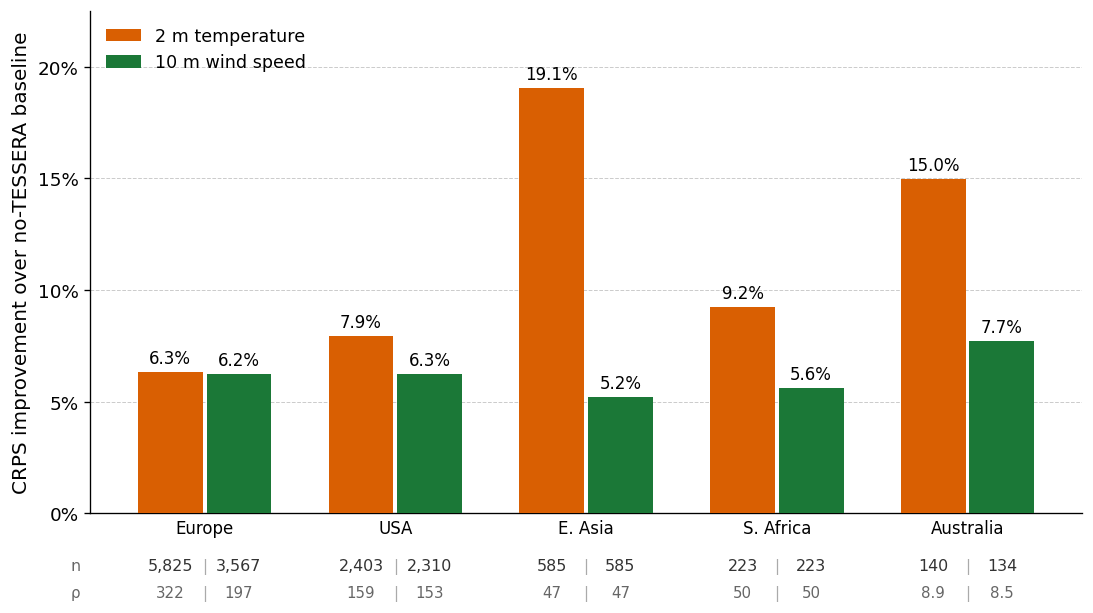

In [12]:
# ============================================================================
# CRPS uplift of TESSERA over the no-TESSERA ConvCNP baseline (+mTPI pair),
# per region, for t2m and wind — grouped bar chart. Regions are ordered by
# total station count (dense -> sparse) so the data-thinning trend is the
# x-axis story.
#
#   uplift% = 100 * (CRPS_no-TESSERA - CRPS_TESSERA) / CRPS_no-TESSERA
#             on the held-out stations, CRPS seed-averaged first (SEEDS).
#
# Station counts: held-out count from <run>/test_summary.json, training count
# from <run>/eval_train_stations/test_summary.json (n_test_stations under
# --station-split train). The tick labels report the TOTAL network size
# n = train + held-out and its density rho = n / bbox area [10^6 km^2], since
# the train/test split is random and it is the network density that matters.
# (Matches the $n$ / $\\rho$ reported in the paper's main results table.)
#
# Reuses _agg / _read / BASE_DIR / SEEDS / BBOX_AREA from the lat16 summary
# cell — run that cell first.
# ============================================================================
import matplotlib.pyplot as plt

PLOT_REGIONS = {  # folder -> (display name, BBOX_AREA key)
    "snapshot_14y_eu":              ("Europe",    "europe"),
    "snapshot_14y_us":              ("USA",       "us"),
    "snapshot_14y_east_asia":       ("E. Asia",   "east_asia"),
    "snapshot_14y_southern_africa": ("S. Africa", "southern_africa"),
    "snapshot_14y_australia":       ("Australia", "australia"),
}
# (variable, display label, colour) -> the (+mTPI baseline, +mTPI TESSERA) pair;
# the TESSERA run resolves from the generation picked in the selector cell.
PLOT_SERIES = [
    ("t2m",  "2 m temperature", "#d95f02",
     ("t2m_snap_bilinear_baseline_mtpi_wd", TESS_RUN_MTPI["t2m"])),
    ("wind", "10 m wind speed", "#1b7837",
     ("wind_truncnormal_snap_bilinear_baseline_mtpi_wd", TESS_RUN_MTPI["wind"])),
]
# Train-station re-evals (eval_train_stations/) exist only for the v1 runs;
# the counts are latents-independent (bounded by the <=10-station set delta),
# so n / rho reuse them for every generation.
TRAIN_COUNT_RUN = {
    "t2m":  "t2m_snap_vae_lat16_concat_with_elev_mtpi_no_static_wd",
    "wind": "wind_truncnormal_snap_vae_lat16_concat_with_elev_mtpi_no_static_wd",
}
SAVE_PATH = None  # e.g. Path("figures/crps_uplift_by_region.png")


def _train_stations(region, run_name, var):
    """Seed-averaged n_test_stations from <run>/eval_train_stations/ (the
    station_split='train' re-eval), or nan if those evals are absent."""
    vals = []
    for s in SEEDS:
        r = _read(BASE_DIR / f"training_runs_{region}" /
                  f"{run_name}_seed{s}" / "eval_train_stations", var)
        if r is not None and r["stations"] == r["stations"]:
            vals.append(r["stations"])
    return float(np.mean(vals)) if vals else float("nan")


# ---- gather ---------------------------------------------------------------
plot_rows = []
for region, (disp, bbox_key) in PLOT_REGIONS.items():
    rec = {"region": region, "label": disp}
    bbox = BBOX_AREA[bbox_key] / 1e6  # 10^6 km^2
    for var, _lab, _col, (base_run, tess_run) in PLOT_SERIES:
        b = _agg(region, base_run, var)
        t = _agg(region + TESS_FOLDER_SUFFIX, tess_run, var)
        rec[f"uplift_{var}"] = (
            (b["crps"] - t["crps"]) / b["crps"] * 100
            if (b and t and b["crps"] == b["crps"] and t["crps"] == t["crps"])
            else float("nan"))
        # Station network for THIS variable: held-out + training stations.
        rec[f"n_test_{var}"] = t["stations"] if t else float("nan")
        rec[f"n_train_{var}"] = _train_stations(region, TRAIN_COUNT_RUN[var], var)
        rec[f"n_total_{var}"] = rec[f"n_test_{var}"] + rec[f"n_train_{var}"]
        rec[f"density_{var}"] = rec[f"n_total_{var}"] / bbox
    plot_rows.append(rec)

plot_df = (pd.DataFrame(plot_rows)
           .sort_values(f"n_total_{PLOT_SERIES[0][0]}", ascending=False)
           .reset_index(drop=True))
display(plot_df)

# ---- plot -----------------------------------------------------------------
xs = np.arange(len(plot_df))
width = 0.34
fig, ax = plt.subplots(figsize=(9.0, 5.0))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for i, (var, lab, col, _runs) in enumerate(PLOT_SERIES):
    off = (i - (len(PLOT_SERIES) - 1) / 2) * (width + 0.02)
    vals = plot_df[f"uplift_{var}"].to_numpy(dtype=float)
    bars = ax.bar(xs + off, vals, width, label=lab, color=col, zorder=3)
    for b, v in zip(bars, vals):
        if v == v:
            ax.annotate(f"{v:.1f}%", (b.get_x() + b.get_width() / 2, v),
                        xytext=(0, 3), textcoords="offset points",
                        ha="center", va="bottom", fontsize=10, color="black")

ax.set_ylabel("CRPS improvement over no-TESSERA baseline")
ax.yaxis.set_major_formatter(lambda v, _p: f"{v:.0f}%")
ax.yaxis.set_major_locator(plt.MultipleLocator(5))
ax.set_ylim(0, max(20.0, np.nanmax(
    [plot_df[f"uplift_{v}"].max() for v, *_ in PLOT_SERIES]) * 1.18))
ax.grid(axis="y", linestyle="--", linewidth=0.6, color="#cccccc", zorder=0)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.set_xlim(-0.6, len(plot_df) - 0.4)
ax.tick_params(axis="x", length=0)

# Three-line region ticks: region name, then per-variable station count n and
# network density rho, each column-aligned under its own bar and separated by
# "|". The tick label itself carries the region name plus two blank lines, so
# the layout engine reserves the height the annotations need.
ax.set_xticks(xs)
ax.set_xticklabels([f"{r.label}\n \n " for r in plot_df.itertuples()],
                   fontsize=10, linespacing=1.6)

N_DY, RHO_DY = -27, -43  # offsets (pt) below the axis for the two label rows


def _fmt_rho(v):
    if v != v:
        return "—"
    return f"{v:.0f}" if v >= 10 else f"{v:.1f}"


def _below(x, dy, text, **kw):
    ax.annotate(text, (x, 0), xycoords=("data", "axes fraction"),
                xytext=(0, dy), textcoords="offset points",
                ha=kw.pop("ha", "center"), va="top", **kw)


for x, r in zip(xs, plot_df.itertuples()):
    for i, (var, *_rest) in enumerate(PLOT_SERIES):
        off = (i - (len(PLOT_SERIES) - 1) / 2) * (width + 0.02)
        n = getattr(r, f"n_total_{var}")
        _below(x + off, N_DY, "—" if n != n else f"{int(n):,}",
               fontsize=9.5, color="#333333")
        _below(x + off, RHO_DY, _fmt_rho(getattr(r, f"density_{var}")),
               fontsize=9, color="#666666")
    for dy in (N_DY, RHO_DY):  # separator between the two variable columns
        _below(x, dy, "|", fontsize=9, color="#aaaaaa")

# Row labels for the two annotation rows, just left of the first group.
for dy, txt, fs in ((N_DY, "n", 9.5), (RHO_DY, "ρ", 9)):
    ax.annotate(txt, (0, 0), xycoords="axes fraction",
                xytext=(-6, dy), textcoords="offset points",
                ha="right", va="top", fontsize=fs, color="#666666")

ax.legend(loc="upper left", frameon=False, fontsize=10.5)
if SAVE_PATH is not None:
    fig.savefig(SAVE_PATH, dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

In [13]:
# ============================================================================
# TRAIN-STATION generalisation table — the +mTPI headline models evaluated on
# the TRAINING stations at the HELD-OUT years (station_split="train",
# split="test"), the companion to the held-out-station tables above.
# Question: does TESSERA's contribution also help at the locations the model
# was FITTED on, or only at unseen held-out ones?
#
# Data source: <run>/eval_train_stations/test_summary.json, produced by
#   projects/tessera_downscaling/scripts/reeval_train_stations.sh
#   (evaluate.py --station-split train --output-dir <run>/eval_train_stations;
#   the no-TESSERA baseline arm is re-run with --filter-vae-latents-path so
#   BOTH arms land on the identical {train ∩ VAE-latent-valid} station set —
#   verified n_test_stations and n_predictions match exactly, e.g. EU t2m
#   4927 == 4927, 6,593,594 preds each). Both models use BILINEAR interpolation
#   (interpolation="bilinear", tessera_method=None); the ONLY difference is the
#   lat16 VAE-latent embedding (TESSERA) concatenated to the input vs none.
#
# Reuses _read / _pm / _fmt / BASE_DIR / SEEDS / REGIONS / _MAE_COL from the
# cell-24 summary block — RUN CELL 24 FIRST. Rows are skipped where
# eval_train_stations/ is not present yet (jobs still running / region not
# covered), so the table fills in as evals land.
# ============================================================================
TRAIN_ST_SUBDIR = "eval_train_stations"

# (var, dist) -> (no-TESSERA baseline +mTPI run, TESSERA lat16 +mTPI run).
TRAIN_ST_PAIRS = {
    ("t2m", "gaussian"): (
        "t2m_snap_bilinear_baseline_mtpi_wd",
        "t2m_snap_vae_lat16_concat_with_elev_mtpi_no_static_wd",
    ),
    ("wind", "truncated_normal"): (
        "wind_truncnormal_snap_bilinear_baseline_mtpi_wd",
        "wind_truncnormal_snap_vae_lat16_concat_with_elev_mtpi_no_static_wd",
    ),
}


def _agg_at(region, run_name, var, subdir=None):
    """Like cell-24 ``_agg`` but reads the eval summary from an optional
    ``<run>/<subdir>/`` (e.g. ``eval_train_stations/``). ``subdir=None`` ->
    the held-out summary in the run-dir root. Returns per-metric
    (mean, sample-std over seeds), or None if no seed has that summary yet."""
    recs = []
    for s in SEEDS:
        rd = BASE_DIR / f"training_runs_{region}" / f"{run_name}_seed{s}"
        if subdir:
            rd = rd / subdir
        r = _read(rd, var)
        if r is not None:
            recs.append(r)
    if not recs:
        return None

    def ms(k):
        vals = [r[k] for r in recs if r[k] is not None and r[k] == r[k]]
        if not vals:
            return float("nan"), float("nan")
        m = float(np.mean(vals))
        sd = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
        return m, sd

    out = {"n_seeds": len(recs)}
    for k in ("mae", "rmse", "nll", "crps", "n", "stations"):
        out[k], out[k + "_std"] = ms(k)
    return out


# ---- Table 1: train-station metrics for the two +mTPI models, per region ----
_ts_rows = []
for region in REGIONS:
    for (var, dist), (base_run, tess_run) in TRAIN_ST_PAIRS.items():
        for label, run in (("no-TESSERA ConvCNP +mTPI", base_run),
                           ("TESSERA lat16 +mTPI", tess_run)):
            a = _agg_at(region, run, var, TRAIN_ST_SUBDIR)
            if a is None:
                continue
            _ts_rows.append({
                "region": region.replace("snapshot_", ""),
                "var": var, "model": label,
                "MAE": _pm(a["mae"], a["mae_std"]),
                "RMSE": _pm(a["rmse"], a["rmse_std"]),
                "CRPS": _pm(a["crps"], a["crps_std"]),
                "Seeds": a["n_seeds"],
                "N": ("—" if a["n"] != a["n"] else f"{int(a['n']):,}"),
                "Stations": ("—" if a["stations"] != a["stations"]
                             else f"{int(a['stations'])}"),
            })
train_st_summary = pd.DataFrame(_ts_rows)

# ---- Table 2: does TESSERA's edge hold on train stations? held-out vs train --
# gap = baseline_MAE - TESSERA_MAE  (positive => TESSERA better). Compared on
# the held-out set (root summary) and the train set (eval_train_stations/).
_gap_rows = []
for region in REGIONS:
    for (var, dist), (base_run, tess_run) in TRAIN_ST_PAIRS.items():
        rec = {"region": region.replace("snapshot_", ""), "var": var}
        have_train = False
        for setname, subdir in (("heldout", None), ("train", TRAIN_ST_SUBDIR)):
            b = _agg_at(region, base_run, var, subdir)
            t = _agg_at(region, tess_run, var, subdir)
            if b is None or t is None:
                rec[f"base_{setname}"] = float("nan")
                rec[f"tess_{setname}"] = float("nan")
                rec[f"gap_{setname}"] = float("nan")
                rec[f"gap%_{setname}"] = float("nan")
                continue
            bm, tm = b["mae"], t["mae"]
            rec[f"base_{setname}"] = bm
            rec[f"tess_{setname}"] = tm
            rec[f"gap_{setname}"] = bm - tm
            rec[f"gap%_{setname}"] = (bm - tm) / bm * 100 if (bm == bm and bm) else float("nan")
            if setname == "train":
                have_train = True
                rec["stations(train)"] = (t["stations"] if t["stations"] == t["stations"] else float("nan"))
        if have_train:
            _gap_rows.append(rec)
train_st_gap = pd.DataFrame(_gap_rows)

# ---- Render ----------------------------------------------------------------
if train_st_summary.empty:
    print("No eval_train_stations/ results found yet — the re-eval jobs are "
          "probably still running.\n  Submit / check: "
          "projects/tessera_downscaling/scripts/reeval_train_stations.sh"
          "  |  squeue --me | grep reeval_trainst")
else:
    train_st_summary = train_st_summary.sort_values(
        ["var", "region", "model"]).reset_index(drop=True)
    print("TRAIN-STATION performance (station_split='train' @ held-out years) "
          "— +mTPI models, across regions.")
    print("MAE/RMSE/CRPS = mean ±sample-std over seeds (head-aware point "
          "estimates: t2m=gaussian mean, wind=trunc-normal median/mean).")
    print("Both arms on the IDENTICAL {train ∩ VAE-valid} stations "
          "(baseline --filter-vae-latents-path matched).\n")
    display(train_st_summary.style.hide(axis="index")
            .set_properties(subset=["MAE", "RMSE", "CRPS"],
                            **{"text-align": "right"}))

    if not train_st_gap.empty:
        train_st_gap = train_st_gap.sort_values(["var", "region"]).reset_index(drop=True)
        show = train_st_gap.copy()
        for c in ("base_heldout", "tess_heldout", "gap_heldout",
                  "base_train", "tess_train", "gap_train"):
            show[c] = show[c].map(lambda v: "—" if v != v else f"{v:.3f}")
        for c in ("gap%_heldout", "gap%_train"):
            show[c] = show[c].map(lambda v: "—" if v != v else f"{v:+.1f}%")
        show["stations(train)"] = show["stations(train)"].map(
            lambda v: "—" if v != v else f"{int(v)}")
        print("\nDoes TESSERA's edge hold on TRAIN stations?  "
              "gap = baseline_MAE − TESSERA_MAE  (positive ⇒ TESSERA better).")
        print("Held-out columns are the standard spatial-holdout metric; train "
              "columns are train-stations @ held-out years.\n")
        display(show[["region", "var",
                      "base_heldout", "tess_heldout", "gap_heldout", "gap%_heldout",
                      "base_train", "tess_train", "gap_train", "gap%_train",
                      "stations(train)"]]
                .style.hide(axis="index"))

        # One-line takeaway per variable: mean train-station gap %.
        print()
        for var in train_st_gap["var"].unique():
            g = train_st_gap[train_st_gap["var"] == var]["gap%_train"].dropna()
            if len(g):
                sign = "helps" if g.mean() > 0 else "hurts"
                print(f"  {var}: TESSERA {sign} on train stations in "
                      f"{int((g > 0).sum())}/{len(g)} regions, "
                      f"mean MAE gap {g.mean():+.1f}%")


TRAIN-STATION performance (station_split='train' @ held-out years) — +mTPI models, across regions.
MAE/RMSE/CRPS = mean ±sample-std over seeds (head-aware point estimates: t2m=gaussian mean, wind=trunc-normal median/mean).
Both arms on the IDENTICAL {train ∩ VAE-valid} stations (baseline --filter-vae-latents-path matched).



region,var,model,MAE,RMSE,CRPS,Seeds,N,Stations
14y_australia,t2m,TESSERA lat16 +mTPI,1.135 ±0.039,1.673 ±0.034,0.828 ±0.023,3,"48,497",126
14y_australia,t2m,no-TESSERA ConvCNP +mTPI,1.347 ±0.197,1.872 ±0.242,0.974 ±0.149,3,"48,497",126
14y_east_asia,t2m,TESSERA lat16 +mTPI,1.112 ±0.025,1.560 ±0.032,0.802 ±0.018,3,"671,107",497
14y_east_asia,t2m,no-TESSERA ConvCNP +mTPI,1.283 ±0.106,1.921 ±0.189,0.918 ±0.070,3,"671,107",497
14y_eu,t2m,TESSERA lat16 +mTPI,1.073 ±0.019,1.538 ±0.031,0.769 ±0.015,3,"6,593,594",4927
14y_eu,t2m,no-TESSERA ConvCNP +mTPI,1.117 ±0.022,1.602 ±0.028,0.803 ±0.016,3,"6,593,594",4927
14y_southern_africa,t2m,TESSERA lat16 +mTPI,1.684 ±0.098,2.623 ±0.098,1.244 ±0.073,3,"188,992",186
14y_southern_africa,t2m,no-TESSERA ConvCNP +mTPI,1.693 ±0.005,2.653 ±0.002,1.246 ±0.003,3,"188,992",186
14y_us,t2m,TESSERA lat16 +mTPI,1.218 ±0.027,1.893 ±0.031,0.886 ±0.020,3,"1,170,200",2046
14y_us,t2m,no-TESSERA ConvCNP +mTPI,1.304 ±0.043,1.975 ±0.054,0.947 ±0.029,3,"1,170,200",2046



Does TESSERA's edge hold on TRAIN stations?  gap = baseline_MAE − TESSERA_MAE  (positive ⇒ TESSERA better).
Held-out columns are the standard spatial-holdout metric; train columns are train-stations @ held-out years.



region,var,base_heldout,tess_heldout,gap_heldout,gap%_heldout,base_train,tess_train,gap_train,gap%_train,stations(train)
14y_australia,t2m,1.573,1.362,0.211,+13.4%,1.347,1.135,0.212,+15.7%,126
14y_east_asia,t2m,1.347,1.106,0.241,+17.9%,1.283,1.112,0.171,+13.3%,497
14y_eu,t2m,1.169,1.109,0.059,+5.1%,1.117,1.073,0.044,+4.0%,4927
14y_southern_africa,t2m,1.998,1.846,0.152,+7.6%,1.693,1.684,0.009,+0.5%,186
14y_us,t2m,1.413,1.281,0.132,+9.4%,1.304,1.218,0.085,+6.5%,2046
14y_australia,wind,1.422,1.213,0.209,+14.7%,1.462,1.205,0.258,+17.6%,121
14y_east_asia,wind,1.231,1.149,0.082,+6.6%,1.046,1.086,-0.040,-3.8%,497
14y_eu,wind,1.283,1.200,0.083,+6.5%,1.256,1.184,0.072,+5.8%,3017
14y_southern_africa,wind,1.231,1.185,0.045,+3.7%,1.219,1.142,0.077,+6.3%,186
14y_us,wind,1.446,1.361,0.085,+5.9%,1.315,1.283,0.033,+2.5%,1969



  t2m: TESSERA helps on train stations in 5/5 regions, mean MAE gap +8.0%
  wind: TESSERA helps on train stations in 4/5 regions, mean MAE gap +5.7%
